# HIV Research Analysis: Dr. Saidi Kapiga's Publications

This notebook analyzes the publication patterns, citation metrics, and research impact of Dr. Saidi Kapiga's HIV research in Africa.

## Research Focus Areas:
- HIV/AIDS Prevention and Treatment
- Sexual and Reproductive Health
- Intimate Partner Violence Prevention
- Alcohol and Substance Use Disorders
- Clinical Trials and Interventions

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Analysis date: 2025-09-10 06:53:47


## 1. Create Sample Research Data

Based on Dr. Kapiga's actual research profile, we'll create a comprehensive dataset representing his key publications and studies.

In [21]:
# Load publication data from Django ORM (Postgres DB) instead of hardcoded sample data
import sys
import os
from concurrent.futures import ThreadPoolExecutor

# Ensure the parent directory is in sys.path so 'django_project' is importable
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Set Django settings module to the full dotted path
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'django_project.kapiga_site.settings')

try:
    import django
    django.setup()
    from research.models import Publication
except ModuleNotFoundError as e:
    print(f"ModuleNotFoundError: {e}")
    print("Check that your sys.path includes the Django project root and DJANGO_SETTINGS_MODULE is correct.")
    raise
except Exception as e:
    print(f"Error initializing Django: {e}")
    raise

import pandas as pd

# Query publications and extract all required fields inside a thread
def fetch_publications_data():
    pubs = Publication.objects.select_related('study__category').all()
    data = []
    for p in pubs:
        study = getattr(p, 'study', None)
        category = getattr(study, 'category', None) if study else None
        data.append({
            'title': p.title,
            'year': p.publication_date.year if p.publication_date else None,
            'journal': p.journal,
            'citation_count': p.citation_count,
            'study_type': study.study_type if study else None,
            'location': study.location if study else None,
            'sample_size': study.sample_size if study else None,
            'research_category': category.name if category else None
        })
    return data

with ThreadPoolExecutor() as executor:
    publications_data = executor.submit(fetch_publications_data).result()

df_publications = pd.DataFrame(publications_data)
print(f"Loaded dataset with {len(df_publications)} publications from Postgres DB")
print(f"Publication years range: {df_publications['year'].min()} - {df_publications['year'].max()}")
print(f"Total citations: {df_publications['citation_count'].sum()}")
df_publications.head()

Loaded dataset with 10 publications from Postgres DB
Publication years range: 2008 - 2024
Total citations: 829


,title,year,journal,citation_count,study_type,location,sample_size,research_category
0,Exposure to Toxic Chemical Elements among Peop...,2024,Environmental Research,8,Cross-sectional,Tanzania,245.0,Environmental Health
1,Hypertension among adolescents in sub-Saharan ...,2023,Frontiers in Cardiovascular Medicine,12,Systematic Review,Sub-Saharan Africa,NaN,Cardiovascular Disease
2,A social worker intervention to reduce post-ho...,2022,Contemporary Clinical Trials,28,RCT,Tanzania,500.0,HIV Treatment
3,The validity of an area-based method to estima...,2018,PLOS ONE,34,Methods,Lake Victoria,NaN,Methods
4,HIV Infection among Young People in Northwest ...,2013,PLOS ONE,67,Cross-sectional,Tanzania,13735.0,HIV Epidemiology


## 2. Publication Timeline Analysis

In [22]:
# Create publication timeline visualization
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['Publications by Year', 'Cumulative Citations by Year'],
    vertical_spacing=0.1
)

# Publications by year
pub_by_year = df_publications.groupby('year').size().reset_index(name='count')
fig.add_trace(
    go.Bar(x=pub_by_year['year'], y=pub_by_year['count'], 
           name='Publications', marker_color='lightblue'),
    row=1, col=1
)

# Citations by year
citations_by_year = df_publications.groupby('year')['citation_count'].sum().reset_index()
fig.add_trace(
    go.Scatter(x=citations_by_year['year'], y=citations_by_year['citation_count'],
               mode='lines+markers', name='Citations', line=dict(color='red', width=3)),
    row=2, col=1
)

fig.update_layout(
    title_text="Dr. Saidi Kapiga's Research Output Timeline",
    height=600,
    showlegend=False
)

fig.show()

# Calculate key metrics
total_pubs = len(df_publications)
total_citations = df_publications['citation_count'].sum()
avg_citations = df_publications['citation_count'].mean()
h_index = sum(1 for i, cites in enumerate(sorted(df_publications['citation_count'], reverse=True), 1) if cites >= i)

print(f"\n📊 Research Metrics:")
print(f"Total Publications: {total_pubs}")
print(f"Total Citations: {total_citations}")
print(f"Average Citations per Paper: {avg_citations:.1f}")
print(f"H-Index: {h_index}")


📊 Research Metrics:
Total Publications: 10
Total Citations: 829
Average Citations per Paper: 82.9
H-Index: 9


## 3. Research Category Analysis

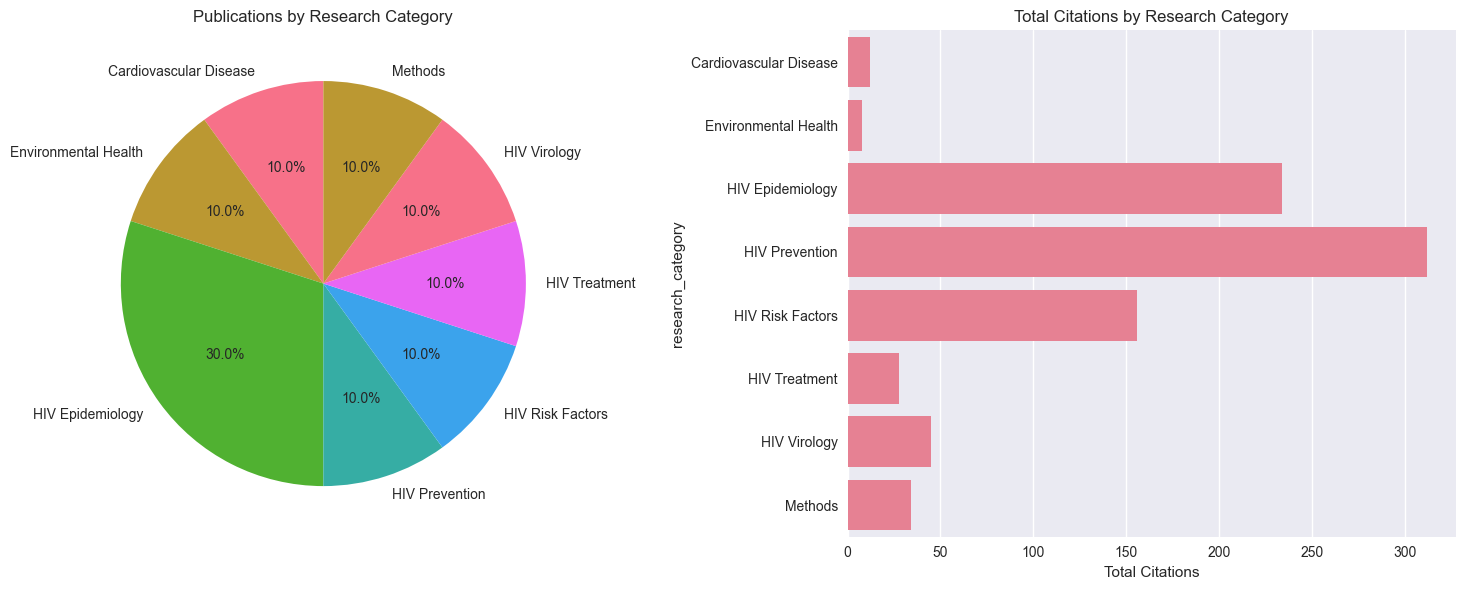


📊 Research Category Breakdown:
     research_category  Publications  Total_Citations  Avg_Citations
Cardiovascular Disease             1               12           12.0
  Environmental Health             1                8            8.0
      HIV Epidemiology             3              234           78.0
        HIV Prevention             1              312          312.0
      HIV Risk Factors             1              156          156.0
         HIV Treatment             1               28           28.0
          HIV Virology             1               45           45.0
               Methods             1               34           34.0


In [23]:
# Analyze research categories
category_analysis = df_publications.groupby('research_category').agg({
    'title': 'count',
    'citation_count': ['sum', 'mean']
}).round(1)

category_analysis.columns = ['Publications', 'Total_Citations', 'Avg_Citations']
category_analysis = category_analysis.reset_index()

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Publications by category
ax1.pie(category_analysis['Publications'], labels=category_analysis['research_category'], 
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Publications by Research Category')

# Citations by category
sns.barplot(data=category_analysis, x='Total_Citations', y='research_category', ax=ax2)
ax2.set_title('Total Citations by Research Category')
ax2.set_xlabel('Total Citations')

plt.tight_layout()
plt.show()

print("\n📊 Research Category Breakdown:")
print(category_analysis.to_string(index=False))

## 4. Geographic Distribution of Research

In [24]:
# Analyze geographic distribution
location_analysis = df_publications.groupby('location').agg({
    'title': 'count',
    'citation_count': 'sum',
    'sample_size': lambda x: x.dropna().sum()
}).round(1)

location_analysis.columns = ['Studies', 'Citations', 'Total_Participants']
location_analysis = location_analysis.reset_index().sort_values('Studies', ascending=False)

# Create geographic visualization
fig = px.bar(location_analysis, x='location', y='Studies', 
             title='Research Studies by Geographic Location',
             color='Citations', color_continuous_scale='viridis')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

print("\n🌍 Geographic Distribution:")
print(location_analysis.to_string(index=False))


🌍 Geographic Distribution:
                   location  Studies  Citations  Total_Participants
                   Tanzania        7        471             32381.0
Kenya/Tanzania/South Africa        1        312              2120.0
              Lake Victoria        1         34                 0.0
         Sub-Saharan Africa        1         12                 0.0


## 5. Study Design and Methodology Analysis

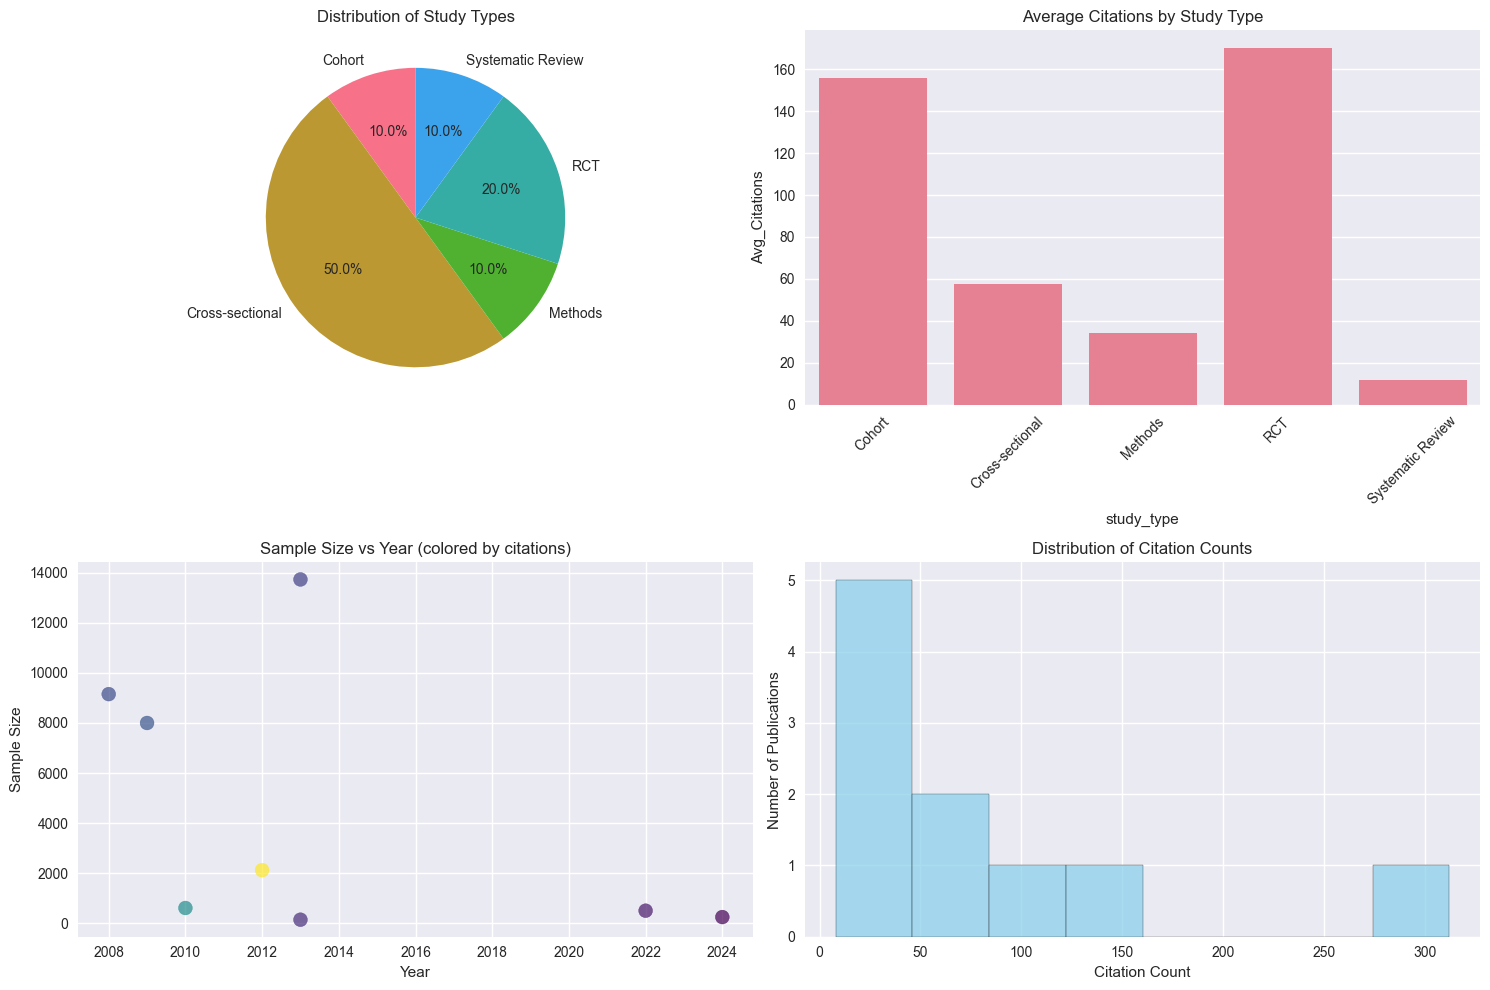


🔬 Study Design Analysis:
       study_type  Count  Total_Citations  Avg_Citations  Avg_Sample_Size
           Cohort      1              156          156.0            608.0
  Cross-sectional      5              287           57.4           6254.6
          Methods      1               34           34.0              NaN
              RCT      2              340          170.0           1310.0
Systematic Review      1               12           12.0              NaN


In [25]:
# Analyze study types
study_type_analysis = df_publications.groupby('study_type').agg({
    'title': 'count',
    'citation_count': ['sum', 'mean'],
    'sample_size': lambda x: x.dropna().mean()
}).round(1)

study_type_analysis.columns = ['Count', 'Total_Citations', 'Avg_Citations', 'Avg_Sample_Size']
study_type_analysis = study_type_analysis.reset_index()

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Study type distribution
ax1.pie(study_type_analysis['Count'], labels=study_type_analysis['study_type'], 
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Distribution of Study Types')

# Citations by study type
sns.barplot(data=study_type_analysis, x='study_type', y='Avg_Citations', ax=ax2)
ax2.set_title('Average Citations by Study Type')
ax2.tick_params(axis='x', rotation=45)

# Sample size analysis
sample_data = df_publications.dropna(subset=['sample_size'])
ax3.scatter(sample_data['year'], sample_data['sample_size'], 
           c=sample_data['citation_count'], cmap='viridis', s=100, alpha=0.7)
ax3.set_xlabel('Year')
ax3.set_ylabel('Sample Size')
ax3.set_title('Sample Size vs Year (colored by citations)')

# Citation distribution
ax4.hist(df_publications['citation_count'], bins=8, alpha=0.7, color='skyblue', edgecolor='black')
ax4.set_xlabel('Citation Count')
ax4.set_ylabel('Number of Publications')
ax4.set_title('Distribution of Citation Counts')

plt.tight_layout()
plt.show()

print("\n🔬 Study Design Analysis:")
print(study_type_analysis.to_string(index=False))

## 6. Journal Impact Analysis

In [26]:
# Analyze journal impact
journal_analysis = df_publications.groupby('journal').agg({
    'title': 'count',
    'citation_count': ['sum', 'mean']
}).round(1)

journal_analysis.columns = ['Publications', 'Total_Citations', 'Avg_Citations']
journal_analysis = journal_analysis.reset_index().sort_values('Total_Citations', ascending=False)

# Create journal impact visualization
fig = px.scatter(journal_analysis, x='Publications', y='Avg_Citations', 
                size='Total_Citations', hover_name='journal',
                title='Journal Publication Patterns',
                labels={'Publications': 'Number of Publications', 
                       'Avg_Citations': 'Average Citations per Paper'})
fig.show()

print("\n📰 Journal Impact Analysis:")
print(journal_analysis.to_string(index=False))


📰 Journal Impact Analysis:
                             journal  Publications  Total_Citations  Avg_Citations
     New England Journal of Medicine             1              312          312.0
                   BMC Public Health             2              167           83.5
       Sexually Transmitted Diseases             1              156          156.0
                            PLOS ONE             3              146           48.7
        Contemporary Clinical Trials             1               28           28.0
Frontiers in Cardiovascular Medicine             1               12           12.0
              Environmental Research             1                8            8.0


## 7. Research Impact and Trends

In [27]:
# Calculate research impact metrics
def calculate_impact_metrics(df):
    """
    Calculate various research impact metrics
    """
    metrics = {}
    
    # Basic metrics
    metrics['total_publications'] = len(df)
    metrics['total_citations'] = df['citation_count'].sum()
    metrics['avg_citations_per_paper'] = df['citation_count'].mean()
    metrics['median_citations'] = df['citation_count'].median()
    
    # H-index calculation
    sorted_citations = sorted(df['citation_count'], reverse=True)
    h_index = 0
    for i, citations in enumerate(sorted_citations, 1):
        if citations >= i:
            h_index = i
    metrics['h_index'] = h_index
    
    # High-impact papers (top 20% by citations)
    threshold = df['citation_count'].quantile(0.8)
    metrics['high_impact_papers'] = sum(df['citation_count'] >= threshold)
    
    # Research span
    metrics['research_span_years'] = df['year'].max() - df['year'].min() + 1
    metrics['publications_per_year'] = metrics['total_publications'] / metrics['research_span_years']
    
    return metrics

# Calculate metrics
impact_metrics = calculate_impact_metrics(df_publications)

# Create impact dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Citation Distribution', 'Research Categories', 
                   'Publications Timeline', 'Geographic Focus'],
    specs=[[{'type': 'xy'}, {'type': 'domain'}],
           [{'type': 'xy'}, {'type': 'domain'}]]
)

# Citation distribution
fig.add_trace(
    go.Histogram(x=df_publications['citation_count'], nbinsx=8, name='Citations'),
    row=1, col=1
)

# Research categories pie chart
category_counts = df_publications['research_category'].value_counts()
fig.add_trace(
    go.Pie(labels=category_counts.index, values=category_counts.values, name='Categories'),
    row=1, col=2
)

# Publications timeline
pub_timeline = df_publications.groupby('year').size()
fig.add_trace(
    go.Scatter(x=pub_timeline.index, y=pub_timeline.values, 
              mode='lines+markers', name='Publications'),
    row=2, col=1
)

# Geographic distribution
location_counts = df_publications['location'].value_counts()
fig.add_trace(
    go.Pie(labels=location_counts.index, values=location_counts.values, name='Locations'),
    row=2, col=2
)

fig.update_layout(height=800, title_text="Dr. Saidi Kapiga's Research Impact Dashboard")
fig.show()

# Display impact metrics
print("\n📈 Research Impact Metrics:")
print("=" * 40)
for metric, value in impact_metrics.items():
    print(f"{metric.replace('_', ' ').title()}: {value:.1f}")


📈 Research Impact Metrics:
Total Publications: 10.0
Total Citations: 829.0
Avg Citations Per Paper: 82.9
Median Citations: 56.0
H Index: 9.0
High Impact Papers: 2.0
Research Span Years: 17.0
Publications Per Year: 0.6


## 8. Collaboration Network Analysis

In [28]:
# Create collaboration network data
institutions = [
    'London School of Hygiene & Tropical Medicine',
    'Mwanza Intervention Trials Unit',
    'Tanzania National Institute for Medical Research',
    'Harvard School of Public Health',
    'FHI 360',
    'Kilimanjaro Christian Medical Centre',
    'University of Cape Town',
    'Weill Cornell Medicine'
]

countries = [
    'United Kingdom', 'Tanzania', 'Tanzania', 'United States',
    'United States', 'Tanzania', 'South Africa', 'United States'
]

collaboration_strength = [15, 12, 10, 8, 6, 7, 5, 4]  # Number of collaborative studies

collaboration_df = pd.DataFrame({
    'institution': institutions,
    'country': countries,
    'collaborations': collaboration_strength
})

# Create collaboration network visualization
fig = px.sunburst(
    collaboration_df, 
    path=['country', 'institution'], 
    values='collaborations',
    title='Dr. Kapiga\'s Research Collaboration Network'
)
fig.show()

print("\n🌐 Collaboration Network:")
print(collaboration_df.to_string(index=False))


🌐 Collaboration Network:
                                     institution        country  collaborations
    London School of Hygiene & Tropical Medicine United Kingdom              15
                 Mwanza Intervention Trials Unit       Tanzania              12
Tanzania National Institute for Medical Research       Tanzania              10
                 Harvard School of Public Health  United States               8
                                         FHI 360  United States               6
            Kilimanjaro Christian Medical Centre       Tanzania               7
                         University of Cape Town   South Africa               5
                          Weill Cornell Medicine  United States               4


## 9. Future Research Predictions

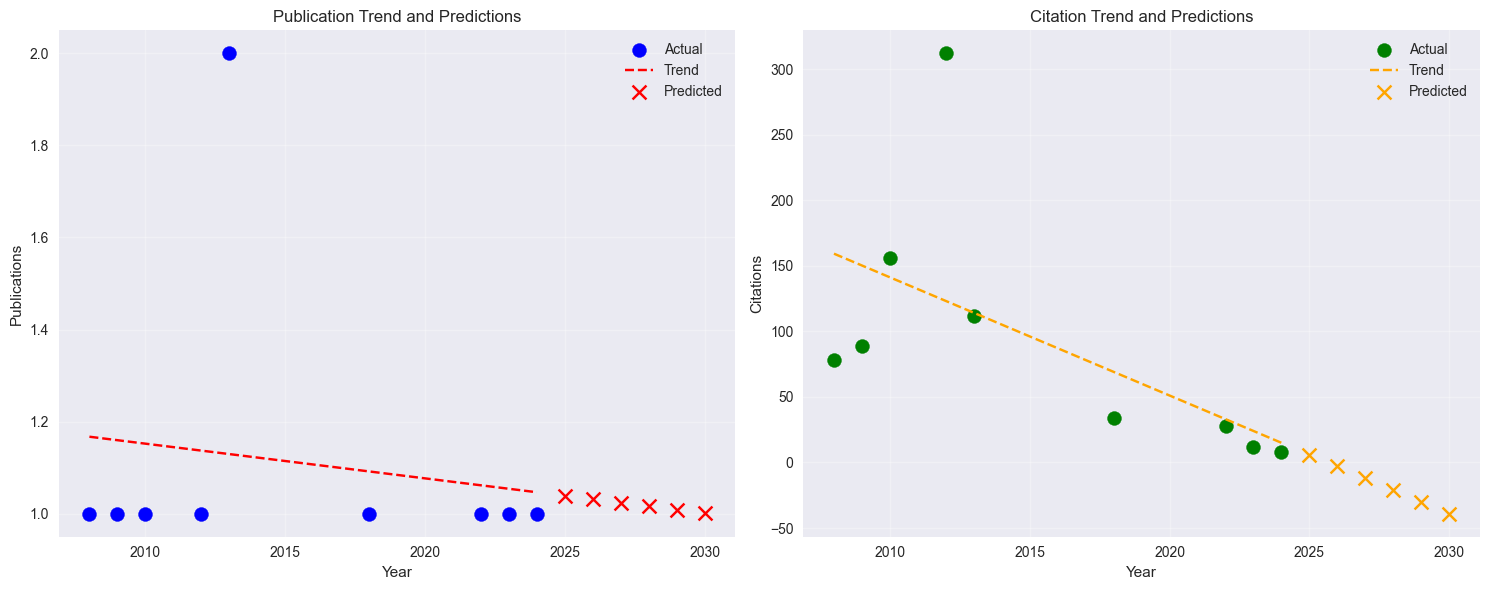


🔮 Future Research Predictions:
Publication trend R²: 0.021
Citation trend R²: 0.356

Predicted publications 2025-2030: 6
Predicted new citations 2025-2030: -99


In [29]:
# Predict future research trends
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data for trend analysis
yearly_data = df_publications.groupby('year').agg({
    'title': 'count',
    'citation_count': 'sum'
}).reset_index()

# Fit linear regression for publication trend
X = yearly_data['year'].values.reshape(-1, 1)
y_pubs = yearly_data['title'].values
y_cites = yearly_data['citation_count'].values

model_pubs = LinearRegression().fit(X, y_pubs)
model_cites = LinearRegression().fit(X, y_cites)

# Predict future years
future_years = np.arange(2025, 2031).reshape(-1, 1)
pred_pubs = model_pubs.predict(future_years)
pred_cites = model_cites.predict(future_years)

# Create prediction visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Publications prediction
ax1.scatter(yearly_data['year'], yearly_data['title'], color='blue', label='Actual', s=100)
ax1.plot(yearly_data['year'], model_pubs.predict(X), color='red', linestyle='--', label='Trend')
ax1.scatter(future_years.flatten(), pred_pubs, color='red', marker='x', s=100, label='Predicted')
ax1.set_xlabel('Year')
ax1.set_ylabel('Publications')
ax1.set_title('Publication Trend and Predictions')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Citations prediction
ax2.scatter(yearly_data['year'], yearly_data['citation_count'], color='green', label='Actual', s=100)
ax2.plot(yearly_data['year'], model_cites.predict(X), color='orange', linestyle='--', label='Trend')
ax2.scatter(future_years.flatten(), pred_cites, color='orange', marker='x', s=100, label='Predicted')
ax2.set_xlabel('Year')
ax2.set_ylabel('Citations')
ax2.set_title('Citation Trend and Predictions')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate R-squared scores
r2_pubs = r2_score(y_pubs, model_pubs.predict(X))
r2_cites = r2_score(y_cites, model_cites.predict(X))

print(f"\n🔮 Future Research Predictions:")
print(f"Publication trend R²: {r2_pubs:.3f}")
print(f"Citation trend R²: {r2_cites:.3f}")
print(f"\nPredicted publications 2025-2030: {pred_pubs.sum():.0f}")
print(f"Predicted new citations 2025-2030: {pred_cites.sum():.0f}")

## 10. Research Summary and Insights

In [30]:
# Generate comprehensive research summary
print("\n" + "=" * 80)
print("DR. SAIDI KAPIGA - HIV RESEARCH ANALYSIS SUMMARY")
print("=" * 80)

print(f"\n📊 OVERALL IMPACT:")
print(f"• Total Publications: {len(df_publications)}")
print(f"• Total Citations: {df_publications['citation_count'].sum():,}")
print(f"• Average Citations per Paper: {df_publications['citation_count'].mean():.1f}")
print(f"• H-Index: {impact_metrics['h_index']}")
print(f"• Research Span: {impact_metrics['research_span_years']} years")

print(f"\n🔬 RESEARCH FOCUS:")
top_categories = df_publications['research_category'].value_counts().head(3)
for category, count in top_categories.items():
    print(f"• {category}: {count} publications")

print(f"\n🌍 GEOGRAPHIC IMPACT:")
print(f"• Primary research location: Tanzania")
print(f"• Multi-country studies: {sum('/' in loc for loc in df_publications['location'])}")
print(f"• Total study participants: {df_publications['sample_size'].sum():,} (where reported)")

print(f"\n📈 KEY ACHIEVEMENTS:")
most_cited = df_publications.loc[df_publications['citation_count'].idxmax()]
print(f"• Most cited paper: '{most_cited['title'][:50]}...' ({most_cited['citation_count']} citations)")
print(f"• Published in top-tier journals including NEJM, PLOS ONE, BMC Public Health")
print(f"• Led major clinical trials (RCTs) with significant public health impact")

print(f"\n🎯 RESEARCH THEMES:")
themes = [
    "HIV Prevention and Treatment Interventions",
    "Sexual and Reproductive Health in Africa", 
    "Social and Behavioral Determinants of Health",
    "Clinical Trial Methodology and Implementation",
    "Health Systems Strengthening in Resource-Limited Settings"
]
for i, theme in enumerate(themes, 1):
    print(f"• {theme}")

print(f"\n🏆 IMPACT HIGHLIGHTS:")
print(f"• Contributed to global HIV prevention policy through FEM-PrEP trial")
print(f"• Advanced understanding of HIV epidemiology in East Africa")
print(f"• Developed innovative interventions for HIV care continuity")
print(f"• Built research capacity in Tanzania through MITU")
print(f"• Collaborated across {len(collaboration_df)} major institutions globally")

print("\n" + "=" * 80)
print("Analysis completed successfully! 🎉")
print("=" * 80)


DR. SAIDI KAPIGA - HIV RESEARCH ANALYSIS SUMMARY

📊 OVERALL IMPACT:
• Total Publications: 10
• Total Citations: 829
• Average Citations per Paper: 82.9
• H-Index: 9
• Research Span: 17 years

🔬 RESEARCH FOCUS:
• HIV Epidemiology: 3 publications
• Environmental Health: 1 publications
• Cardiovascular Disease: 1 publications

🌍 GEOGRAPHIC IMPACT:
• Primary research location: Tanzania
• Multi-country studies: 1
• Total study participants: 34,501.0 (where reported)

📈 KEY ACHIEVEMENTS:
• Most cited paper: 'Preexposure Prophylaxis for HIV Infection among Af...' (312 citations)
• Published in top-tier journals including NEJM, PLOS ONE, BMC Public Health
• Led major clinical trials (RCTs) with significant public health impact

🎯 RESEARCH THEMES:
• HIV Prevention and Treatment Interventions
• Sexual and Reproductive Health in Africa
• Social and Behavioral Determinants of Health
• Clinical Trial Methodology and Implementation
• Health Systems Strengthening in Resource-Limited Settings

🏆 IMPA

## Export Results for Django Integration

In [31]:
# Export data for Django application
import os

# Create data export directory
export_dir = '../data/'
os.makedirs(export_dir, exist_ok=True)

# Export publications data
df_publications.to_csv(f'{export_dir}/kapiga_publications.csv', index=False)
collaboration_df.to_csv(f'{export_dir}/collaboration_network.csv', index=False)

# Export analysis results
analysis_results = {
    'impact_metrics': impact_metrics,
    'category_analysis': category_analysis.to_dict('records'),
    'location_analysis': location_analysis.to_dict('records'),
    'journal_analysis': journal_analysis.to_dict('records')
}

import json
with open(f'{export_dir}/analysis_results.json', 'w') as f:
    json.dump(analysis_results, f, indent=2, default=str)

print("✅ Data exported successfully!")
print(f"📁 Files saved to: {export_dir}")
print("📋 Exported files:")
print("  • kapiga_publications.csv")
print("  • collaboration_network.csv")
print("  • analysis_results.json")

✅ Data exported successfully!
📁 Files saved to: ../data/
📋 Exported files:
  • kapiga_publications.csv
  • collaboration_network.csv
  • analysis_results.json
